# Treatment Effects

# Scenario

A company offers some customers a discount. We want to know whether the discount increases later engagement. But customers who receive or use discounts may differ from those who do not. More engaged customers may be more likely to receive a discount, and more motivated customers may be more likely to use one. So a simple comparison of treated vs. untreated customers may be misleading.

| Concept                    | Lesson variable               |
| -------------------------- | ----------------------------- |
| Unit                       | `Customer`                    |
| Treatment                  | `discount` or `discount_used` |
| Instrument / encouragement | `discount_offer`              |
| Outcome                    | `later_engagement`            |
| Covariate                  | `initial_engagement`          |
| Unobserved confounder      | `motivation_unobserved`       |

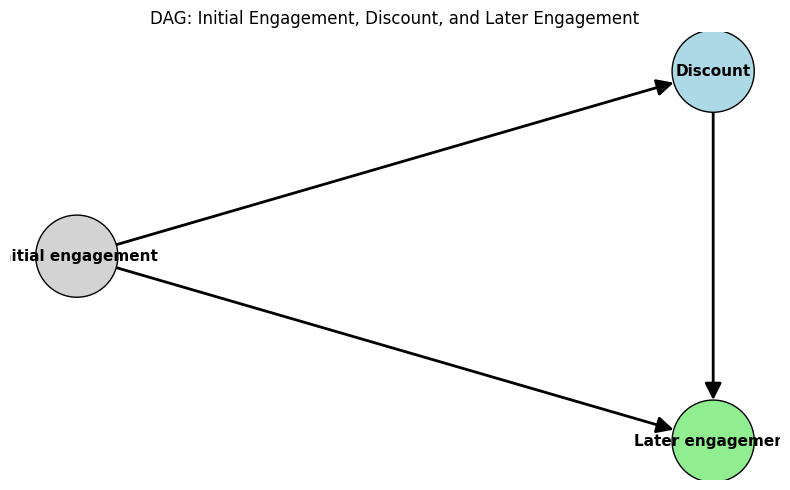

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

dag = nx.DiGraph()

dag.add_edges_from([
    ("Initial engagement", "Discount"),
    ("Initial engagement", "Later engagement"),
    ("Discount", "Later engagement")
])

pos = {
    "Initial engagement": (0, 1),
    "Discount": (2, 1.7),
    "Later engagement": (2, 0.3)
}

plt.figure(figsize=(8, 5))

nx.draw_networkx_nodes(
    dag,
    pos,
    node_size=3500,
    node_color=["lightgray", "lightblue", "lightgreen"],
    edgecolors="black"
)

nx.draw_networkx_labels(
    dag,
    pos,
    font_size=11,
    font_weight="bold"
)

nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=2,
    node_size=3500,
    edge_color="black",
    connectionstyle="arc3,rad=0.0"
)

plt.title("DAG: Initial Engagement, Discount, and Later Engagement")
plt.axis("off")
plt.tight_layout()
plt.show()

This lesson is about how causal inference tries to answer questions of the form:

### What would have happened to the same unit if it had received a different treatment condition?

# Outline of topics

Potential outcomes and model-based counterfactual prediction

## ATE: Average Treatment Effect
## ATE with matching
## ATE with interaction: heterogeneous treatment effects
## ATT: Average Treatment Effect on the Treated
## ATU / ATUT: Average Treatment Effect on the Untreated
## CATE: Conditional Average Treatment Effect
## LATE: Local Average Treatment Effect using an instrument

# Summary: how all estimands differ

| Estimand   | Averaging population                | Informal question                                                                   |
| ---------- | ----------------------------------- | ----------------------------------------------------------------------------------- |
| ATE        | Everyone                            | What would be the average effect if everyone got the discount versus no one got it? |
| ATT        | Treated customers                   | How much did the discount help the customers who actually received it?              |
| ATU / ATUT | Untreated customers                 | How much would the discount have helped customers who did not receive it?           |
| CATE       | A subgroup or covariate value       | Is the effect different for high-engagement versus low-engagement customers?        |
| LATE       | Compliers affected by an instrument | What is the effect for customers whose discount usage changes because of the offer? |

In [ ]:
(1.5 * 0.5 + 2.0 * 1 + 0.25) - (1.5 * 0.5 + 2.0 * 0 + 0.25) = 2
(1.5 * (-0.2) + 2.0 * 1 + 0.25) - (1.5 * (-0.2) + 2.0 * 0 + 0.25) = 2
2
2
(2 + 2 + 2 + 2)/4 = 2

In [11]:
(2.0 - (1.5 * 0.5 + 2.0 * 0 + 0.25) + \
0.8 - (1.5 * (-0.2) + 2.0 * 0 + 0.25) + \
(1.5 * 1.1 + 2.0 * 1 + 0.25) - 1.4 + \
(1.5 * (-0.7) + 2.0 * 1 + 0.25) - (-0.3))/4

1.4625

In [ ]:
A * initial + B * discount + C
Model both
0 (1.5 * 0.5 + 2.0 * 1 + 0.25) - (1.5 * 0.5 + 2.0 * 0 + 0.25) = ?
1 model value - model value
2 model value - model value
3 model value - model value
(? + ? + ? + ?) / 4 = ?

Use true value
0 2.0 - (1.5 * 0.5 + 2.0 * 0 + 0.25) = ?
1 true value - model value
2 model value - true value
3 model value - true value
(? + ? + ? + ?) / 4 = ?

For this puzzle, use these chosen model values:
A = 1.5
B = 2.0
C = 0.25

Puzzle data
   initial_engagement  discount  observed_later_engagement
0                 0.5         1                        2.0
1                -0.2         1                        0.8
2                 1.1         0                        1.4
3                -0.7         0                       -0.3

# Average Treatment Effect

In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 20

initial_engagement = np.random.normal(loc=0, scale=1, size=n)

logit = -0.2 + 1.2 * initial_engagement
prob_discount = 1 / (1 + np.exp(-logit))

discount = np.random.binomial(n=1, p=prob_discount, size=n)

noise = np.random.normal(loc=0, scale=0.5, size=n)
later_engagement = discount + initial_engagement + noise

data = pd.DataFrame({
    "initial_engagement": initial_engagement,
    "discount": discount,
    "later_engagement": later_engagement
})

print("Puzzle")
print("Suppose the four rows below were the only rows in the table.")
print("The goal is to compute the model-based ATE using the prediction equation:")
print()
print("predicted_later_engagement = A * initial_engagement + B * discount + C")
print()
print("For each row, predict later_engagement twice:")
print("1. Once with discount = 1")
print("2. Once with discount = 0")
print()
print("Keep initial_engagement the same in both predictions.")
print()
print("Then compute:")
print()
print("ATE = mean(predicted later_engagement if discount = 1)")
print("      - mean(predicted later_engagement if discount = 0)")
print()

A = 1.5
B = 2.0
C = 0.25

print("For this puzzle, use these chosen model values:")
print("A =", A)
print("B =", B)
print("C =", C)
print()

puzzle_data = pd.DataFrame({
    "initial_engagement": [0.50, -0.20, 1.10, -0.70],
    "discount": [1, 1, 0, 0],
    "observed_later_engagement": [2.00, 0.80, 1.40, -0.30]
})

print("Puzzle data")
print(puzzle_data)
print()

print("Original dataset")
print(data)

X_model = data[["discount", "initial_engagement"]]
y_model = data["later_engagement"]

model = LinearRegression()
model.fit(X_model, y_model)

data_discount_to_no_discount = data.copy()

mask_discount_1 = data_discount_to_no_discount["discount"] == 1

counterfactual_X_0 = data_discount_to_no_discount.loc[
    mask_discount_1,
    ["discount", "initial_engagement"]
].copy()

counterfactual_X_0["discount"] = 0

data_discount_to_no_discount.loc[
    mask_discount_1,
    "later_engagement"
] = model.predict(counterfactual_X_0)

data_if_discount_1 = data.copy()
data_if_discount_1["discount"] = 1
data_if_discount_1["later_engagement"] = model.predict(
    data_if_discount_1[["discount", "initial_engagement"]]
)

print("Data if discount is 1")
print(data_if_discount_1)

data_if_discount_0 = data.copy()
data_if_discount_0["discount"] = 0
data_if_discount_0["later_engagement"] = model.predict(
    data_if_discount_0[["discount", "initial_engagement"]]
)

print("Data if discount is 0")
print(data_if_discount_0)

ate = (
    data_if_discount_1["later_engagement"].mean()
    - data_if_discount_0["later_engagement"].mean()
)

print(ate)

print()
print("Puzzle answer")
print("The puzzle used this prediction equation:")
print()
print("predicted_later_engagement = A * initial_engagement + B * discount + C")
print()
print("with:")
print("A =", A)
print("B =", B)
print("C =", C)
print()

puzzle_if_discount_1 = puzzle_data.copy()
puzzle_if_discount_1["discount"] = 1
puzzle_if_discount_1["predicted_later_engagement"] = (
    A * puzzle_if_discount_1["initial_engagement"]
    + B * puzzle_if_discount_1["discount"]
    + C
)

puzzle_if_discount_0 = puzzle_data.copy()
puzzle_if_discount_0["discount"] = 0
puzzle_if_discount_0["predicted_later_engagement"] = (
    A * puzzle_if_discount_0["initial_engagement"]
    + B * puzzle_if_discount_0["discount"]
    + C
)

print("Puzzle predictions if discount = 1 for everyone")
print(puzzle_if_discount_1[[
    "initial_engagement",
    "discount",
    "predicted_later_engagement"
]])
print()

print("Puzzle predictions if discount = 0 for everyone")
print(puzzle_if_discount_0[[
    "initial_engagement",
    "discount",
    "predicted_later_engagement"
]])
print()

mean_if_discount_1 = puzzle_if_discount_1["predicted_later_engagement"].mean()
mean_if_discount_0 = puzzle_if_discount_0["predicted_later_engagement"].mean()
puzzle_ate = mean_if_discount_1 - mean_if_discount_0

print("mean predicted later_engagement if discount = 1 =", mean_if_discount_1)
print("mean predicted later_engagement if discount = 0 =", mean_if_discount_0)
print()
print("Puzzle ATE = mean if discount = 1 - mean if discount = 0")
print("Puzzle ATE =", mean_if_discount_1, "-", mean_if_discount_0)
print("Puzzle ATE =", puzzle_ate)

Puzzle
Suppose the four rows below were the only rows in the table.
The goal is to compute the model-based ATE using the prediction equation:

predicted_later_engagement = A * initial_engagement + B * discount + C

For each row, predict later_engagement twice:
1. Once with discount = 1
2. Once with discount = 0

Keep initial_engagement the same in both predictions.

Then compute:

ATE = mean(predicted later_engagement if discount = 1)
      - mean(predicted later_engagement if discount = 0)

For this puzzle, use these chosen model values:
A = 1.5
B = 2.0
C = 0.25

Puzzle data
   initial_engagement  discount  observed_later_engagement
0                 0.5         1                        2.0
1                -0.2         1                        0.8
2                 1.1         0                        1.4
3                -0.7         0                       -0.3

Original dataset
    initial_engagement  discount  later_engagement
0             0.496714         1          1.907987
1 

In [14]:
((2.0 - 1.1) + (2.2 - 1.1) + (2.1 - 1.1) + (2.0 - (-0.3)))/4

1.325

In [ ]:
Puzzle data
   initial_engagement  discount  observed_later_engagement
0                0.50         1                        2.0
1                0.60         1                        2.2
2                0.55         0                        1.1
3               -0.70         0                       -0.3

# ATE with matching

In [11]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)

n = 20

initial_engagement = np.random.normal(loc=0, scale=1, size=n)

logit = -0.2 + 1.2 * initial_engagement
prob_discount = 1 / (1 + np.exp(-logit))

discount = np.random.binomial(n=1, p=prob_discount, size=n)

noise = np.random.normal(loc=0, scale=0.5, size=n)
later_engagement = discount + initial_engagement + noise

data = pd.DataFrame({
    "initial_engagement": initial_engagement,
    "discount": discount,
    "later_engagement": later_engagement
})

print("Puzzle")
print("Suppose the four rows below were the only rows in the table.")
print("The goal is to compute a matching-based ATE.")
print()
print("Use initial_engagement as the confounder used for matching.")
print()
print("For each treated row, find the untreated row with the closest initial_engagement.")
print("Use that untreated row as the estimate of what would have happened to the")
print("treated row if it had not received the discount.")
print()
print("For each untreated row, find the treated row with the closest initial_engagement.")
print("Use that treated row as the estimate of what would have happened to the")
print("untreated row if it had received the discount.")
print()
print("Then compute one estimated treatment effect for each row:")
print()
print("If the row is treated:")
print("estimated effect = observed later_engagement - matched untreated later_engagement")
print()
print("If the row is untreated:")
print("estimated effect = matched treated later_engagement - observed later_engagement")
print()
print("Finally compute:")
print()
print("matching-based ATE = mean of the four estimated treatment effects")
print()

puzzle_data = pd.DataFrame({
    "initial_engagement": [0.50, 0.60, 0.55, -0.70],
    "discount": [1, 1, 0, 0],
    "observed_later_engagement": [2.00, 2.20, 1.10, -0.30]
})

print("Puzzle data")
print(puzzle_data)
print()

print("Original dataset")
print(data)
print()

treated = data[data["discount"] == 1].copy()
untreated = data[data["discount"] == 0].copy()

matching_variable = ["initial_engagement"]

nn_for_treated = NearestNeighbors(n_neighbors=1)
nn_for_treated.fit(untreated[matching_variable])

distances_to_untreated, indices_to_untreated = nn_for_treated.kneighbors(
    treated[matching_variable]
)

treated_matches = treated.copy()

treated_matches["matched_index"] = untreated.iloc[
    indices_to_untreated.flatten()
].index.values

treated_matches["matched_initial_engagement"] = untreated.iloc[
    indices_to_untreated.flatten()
]["initial_engagement"].values

treated_matches["matched_later_engagement"] = untreated.iloc[
    indices_to_untreated.flatten()
]["later_engagement"].values

treated_matches["match_distance"] = distances_to_untreated.flatten()

treated_matches["estimated_treatment_effect"] = (
    treated_matches["later_engagement"]
    - treated_matches["matched_later_engagement"]
)

nn_for_untreated = NearestNeighbors(n_neighbors=1)
nn_for_untreated.fit(treated[matching_variable])

distances_to_treated, indices_to_treated = nn_for_untreated.kneighbors(
    untreated[matching_variable]
)

untreated_matches = untreated.copy()

untreated_matches["matched_index"] = treated.iloc[
    indices_to_treated.flatten()
].index.values

untreated_matches["matched_initial_engagement"] = treated.iloc[
    indices_to_treated.flatten()
]["initial_engagement"].values

untreated_matches["matched_later_engagement"] = treated.iloc[
    indices_to_treated.flatten()
]["later_engagement"].values

untreated_matches["match_distance"] = distances_to_treated.flatten()

untreated_matches["estimated_treatment_effect"] = (
    untreated_matches["matched_later_engagement"]
    - untreated_matches["later_engagement"]
)

ate_matches = pd.concat([
    treated_matches,
    untreated_matches
])

ate = ate_matches["estimated_treatment_effect"].mean()

print("Matching table for ATE")
print(ate_matches[[
    "initial_engagement",
    "discount",
    "later_engagement",
    "matched_index",
    "matched_initial_engagement",
    "matched_later_engagement",
    "match_distance",
    "estimated_treatment_effect"
]])
print()

print("Matching-based ATE")
print(ate)

print()
print("Puzzle answer")
print("The puzzle uses matching on initial_engagement.")
print()

puzzle_treated = puzzle_data[puzzle_data["discount"] == 1].copy()
puzzle_untreated = puzzle_data[puzzle_data["discount"] == 0].copy()

puzzle_nn_for_treated = NearestNeighbors(n_neighbors=1)
puzzle_nn_for_treated.fit(puzzle_untreated[matching_variable])

puzzle_distances_to_untreated, puzzle_indices_to_untreated = (
    puzzle_nn_for_treated.kneighbors(puzzle_treated[matching_variable])
)

puzzle_treated_matches = puzzle_treated.copy()

puzzle_treated_matches["matched_index"] = puzzle_untreated.iloc[
    puzzle_indices_to_untreated.flatten()
].index.values

puzzle_treated_matches["matched_initial_engagement"] = puzzle_untreated.iloc[
    puzzle_indices_to_untreated.flatten()
]["initial_engagement"].values

puzzle_treated_matches["matched_later_engagement"] = puzzle_untreated.iloc[
    puzzle_indices_to_untreated.flatten()
]["observed_later_engagement"].values

puzzle_treated_matches["match_distance"] = puzzle_distances_to_untreated.flatten()

puzzle_treated_matches["estimated_treatment_effect"] = (
    puzzle_treated_matches["observed_later_engagement"]
    - puzzle_treated_matches["matched_later_engagement"]
)

puzzle_nn_for_untreated = NearestNeighbors(n_neighbors=1)
puzzle_nn_for_untreated.fit(puzzle_treated[matching_variable])

puzzle_distances_to_treated, puzzle_indices_to_treated = (
    puzzle_nn_for_untreated.kneighbors(puzzle_untreated[matching_variable])
)

puzzle_untreated_matches = puzzle_untreated.copy()

puzzle_untreated_matches["matched_index"] = puzzle_treated.iloc[
    puzzle_indices_to_treated.flatten()
].index.values

puzzle_untreated_matches["matched_initial_engagement"] = puzzle_treated.iloc[
    puzzle_indices_to_treated.flatten()
]["initial_engagement"].values

puzzle_untreated_matches["matched_later_engagement"] = puzzle_treated.iloc[
    puzzle_indices_to_treated.flatten()
]["observed_later_engagement"].values

puzzle_untreated_matches["match_distance"] = puzzle_distances_to_treated.flatten()

puzzle_untreated_matches["estimated_treatment_effect"] = (
    puzzle_untreated_matches["matched_later_engagement"]
    - puzzle_untreated_matches["observed_later_engagement"]
)

puzzle_ate_matches = pd.concat([
    puzzle_treated_matches,
    puzzle_untreated_matches
])

puzzle_ate = puzzle_ate_matches["estimated_treatment_effect"].mean()

print("Puzzle matching table for ATE")
print(puzzle_ate_matches[[
    "initial_engagement",
    "discount",
    "observed_later_engagement",
    "matched_index",
    "matched_initial_engagement",
    "matched_later_engagement",
    "match_distance",
    "estimated_treatment_effect"
]])
print()

print("Puzzle matching-based ATE")
print(puzzle_ate)

factual: 2.0 - counterfactual: 1.1
factual - counterfactual
counterfactual - factual
counterfactual - factual 

   initial_engagement  discount  observed_later_engagement
0                0.50         1                        2.0
1                0.60         1                        2.2
2                0.55         0                        1.1
3               -0.70         0                       -0.3

Puzzle
Suppose the four rows below were the only rows in the table.
The goal is to compute a matching-based ATE.

Use initial_engagement as the confounder used for matching.

For each treated row, find the untreated row with the closest initial_engagement.
Use that untreated row as the estimate of what would have happened to the
treated row if it had not received the discount.

For each untreated row, find the treated row with the closest initial_engagement.
Use that treated row as the estimate of what would have happened to the
untreated row if it had received the discount.

Then compute one estimated treatment effect for each row:

If the row is treated:
estimated effect = observed later_engagement - matched untreated later_engagement

If the row is untreated:
estimated effect = matched treated later_engagement - observed later_engagement

Finally compute:

matching-based ATE = mean of the four estimated treatment effects

Puzzle data
   initial_engagement  discount  observed_later_e

In [17]:
((1.5 * 0.5 + 2.0 * 1 + 0.75 * 0.5 + 0.25) - (1.5 * 0.5 + 2.0 * 0 + 0.75 * 0 + 0.25) + \
+ (1.5 * (-0.2) + 2.0 * 1 + 0.75 * (-0.2) + 0.25) - (1.5 * (-0.2) + 2.0 * 0 + 0.75 * 0 + 0.25) + \
+ (1.5 * (1.1) + 2.0 * 1 + 0.75 * (1.1) + 0.25) - (1.5 * (1.1) + 2.0 * 0 + 0.75 * 0 + 0.25) + \
+ (1.5 * (-0.7) + 2.0 * 1 + 0.75 * (-0.7) + 0.25) - (1.5 * (-0.7) + 2.0 * 0 + 0.75 * 0 + 0.25))/4

2.1312499999999996

In [ ]:
(A * initial + B * discount + D * initial * discount + C)

A = 1.5
B = 2.0
D = 0.75
C = 0.25

Puzzle data
   initial_engagement  discount  discount_initial_engagement  \
0                 0.5         1                          0.5   
1                -0.2         1                         -0.2   
2                 1.1         0                          0.0   
3                -0.7         0                         -0.0   

   observed_later_engagement  
0                        2.0  
1                        0.8  
2                        1.4  
3                       -0.3

# Average Treatment Effect with interaction term

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(42)

n = 20

initial_engagement = np.random.normal(loc=0, scale=1, size=n)

logit = -0.2 + 1.2 * initial_engagement
prob_discount = 1 / (1 + np.exp(-logit))

discount = np.random.binomial(n=1, p=prob_discount, size=n)

discount_initial_engagement = discount * initial_engagement

noise = np.random.normal(loc=0, scale=0.5, size=n)

later_engagement = (
    discount
    + initial_engagement
    + discount_initial_engagement
    + noise
)

data = pd.DataFrame({
    "initial_engagement": initial_engagement,
    "discount": discount,
    "discount_initial_engagement": discount_initial_engagement,
    "later_engagement": later_engagement
})

print("Puzzle")
print("Suppose the four rows below were the only rows in the table.")
print("The goal is to compute the model-based ATE using a prediction equation")
print("that includes an interaction effect.")
print()
print("The prediction equation is:")
print()
print("predicted_later_engagement =")
print("    A * initial_engagement")
print("    + B * discount")
print("    + D * discount_initial_engagement")
print("    + C")
print()
print("where:")
print()
print("discount_initial_engagement = discount * initial_engagement")
print()
print("For each row, predict later_engagement twice:")
print("1. Once with discount = 1")
print("2. Once with discount = 0")
print()
print("Important:")
print("When discount changes, discount_initial_engagement must also be recalculated.")
print()
print("If discount = 1:")
print("discount_initial_engagement = 1 * initial_engagement")
print()
print("If discount = 0:")
print("discount_initial_engagement = 0 * initial_engagement = 0")
print()
print("Then compute:")
print()
print("ATE = mean(predicted later_engagement if discount = 1)")
print("      - mean(predicted later_engagement if discount = 0)")
print()

A = 1.5
B = 2.0
D = 0.75
C = 0.25

print("For this puzzle, use these chosen model values:")
print("A =", A)
print("B =", B)
print("D =", D)
print("C =", C)
print()

puzzle_data = pd.DataFrame({
    "initial_engagement": [0.50, -0.20, 1.10, -0.70],
    "discount": [1, 1, 0, 0],
    "observed_later_engagement": [2.00, 0.80, 1.40, -0.30]
})

puzzle_data["discount_initial_engagement"] = (
    puzzle_data["discount"] * puzzle_data["initial_engagement"]
)

puzzle_data = puzzle_data[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "observed_later_engagement"
]]

print("Puzzle data")
print(puzzle_data)
print()

print("Original dataset")
print(data)

X_model = data[[
    "discount",
    "initial_engagement",
    "discount_initial_engagement"
]]

y_model = data["later_engagement"]

model = LinearRegression()
model.fit(X_model, y_model)

print("\nModel intercept")
print(model.intercept_)

print("\nModel coefficients")
print(pd.Series(model.coef_, index=X_model.columns))

data_if_discount_1 = data.copy()
data_if_discount_1["discount"] = 1
data_if_discount_1["discount_initial_engagement"] = (
    data_if_discount_1["discount"]
    * data_if_discount_1["initial_engagement"]
)

data_if_discount_1["later_engagement"] = model.predict(
    data_if_discount_1[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nData if discount is 1")
print(data_if_discount_1)

data_if_discount_0 = data.copy()
data_if_discount_0["discount"] = 0
data_if_discount_0["discount_initial_engagement"] = (
    data_if_discount_0["discount"]
    * data_if_discount_0["initial_engagement"]
)

data_if_discount_0["later_engagement"] = model.predict(
    data_if_discount_0[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nData if discount is 0")
print(data_if_discount_0)

ate = (
    data_if_discount_1["later_engagement"].mean()
    - data_if_discount_0["later_engagement"].mean()
)

print("\nEstimated ATE")
print(ate)

print()
print("Puzzle answer")
print("The puzzle used this prediction equation:")
print()
print("predicted_later_engagement =")
print("    A * initial_engagement")
print("    + B * discount")
print("    + D * discount_initial_engagement")
print("    + C")
print()
print("where:")
print("discount_initial_engagement = discount * initial_engagement")
print()
print("with:")
print("A =", A)
print("B =", B)
print("D =", D)
print("C =", C)
print()

puzzle_if_discount_1 = puzzle_data.copy()
puzzle_if_discount_1["discount"] = 1
puzzle_if_discount_1["discount_initial_engagement"] = (
    puzzle_if_discount_1["discount"]
    * puzzle_if_discount_1["initial_engagement"]
)

puzzle_if_discount_1["predicted_later_engagement"] = (
    A * puzzle_if_discount_1["initial_engagement"]
    + B * puzzle_if_discount_1["discount"]
    + D * puzzle_if_discount_1["discount_initial_engagement"]
    + C
)

puzzle_if_discount_0 = puzzle_data.copy()
puzzle_if_discount_0["discount"] = 0
puzzle_if_discount_0["discount_initial_engagement"] = (
    puzzle_if_discount_0["discount"]
    * puzzle_if_discount_0["initial_engagement"]
)

puzzle_if_discount_0["predicted_later_engagement"] = (
    A * puzzle_if_discount_0["initial_engagement"]
    + B * puzzle_if_discount_0["discount"]
    + D * puzzle_if_discount_0["discount_initial_engagement"]
    + C
)

print("Puzzle predictions if discount = 1 for everyone")
print(puzzle_if_discount_1[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "predicted_later_engagement"
]])
print()

print("Puzzle predictions if discount = 0 for everyone")
print(puzzle_if_discount_0[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "predicted_later_engagement"
]])
print()

mean_if_discount_1 = puzzle_if_discount_1["predicted_later_engagement"].mean()
mean_if_discount_0 = puzzle_if_discount_0["predicted_later_engagement"].mean()
puzzle_ate = mean_if_discount_1 - mean_if_discount_0

print("mean predicted later_engagement if discount = 1 =", mean_if_discount_1)
print("mean predicted later_engagement if discount = 0 =", mean_if_discount_0)
print()
print("Puzzle ATE = mean if discount = 1 - mean if discount = 0")
print("Puzzle ATE =", mean_if_discount_1, "-", mean_if_discount_0)
print("Puzzle ATE =", puzzle_ate)

print()
print("Because this model has an interaction effect, the treatment effect is not")
print("just B for every row.")
print()
print("For one row:")
print("effect of discount = prediction if discount = 1 - prediction if discount = 0")
print("effect of discount = B + D * initial_engagement")
print()
print("So the ATE over these four rows is:")
print("average of B + D * initial_engagement over the four rows")
print()

row_level_effects = B + D * puzzle_data["initial_engagement"]

print("Row-level treatment effects")
print(row_level_effects)
print()
print("Average row-level treatment effect =", row_level_effects.mean())

Puzzle
Suppose the four rows below were the only rows in the table.
The goal is to compute the model-based ATE using a prediction equation
that includes an interaction effect.

The prediction equation is:

predicted_later_engagement =
    A * initial_engagement
    + B * discount
    + D * discount_initial_engagement
    + C

where:

discount_initial_engagement = discount * initial_engagement

For each row, predict later_engagement twice:
1. Once with discount = 1
2. Once with discount = 0

Important:
When discount changes, discount_initial_engagement must also be recalculated.

If discount = 1:
discount_initial_engagement = 1 * initial_engagement

If discount = 0:
discount_initial_engagement = 0 * initial_engagement = 0

Then compute:

ATE = mean(predicted later_engagement if discount = 1)
      - mean(predicted later_engagement if discount = 0)

For this puzzle, use these chosen model values:
A = 1.5
B = 2.0
D = 0.75
C = 0.25

Puzzle data
   initial_engagement  discount  discount_ini

# Average Treatment Effect on the Treated with interaction term

In [14]:
print("Puzzle")
print("Suppose the four rows below were selected from a larger table.")
print("There are two treated rows and two untreated rows.")
print()
print("For this puzzle, compute the model-based ATT.")
print()
print("ATT means Average Treatment effect on the Treated.")
print("So only use the rows where discount = 1.")
print("Ignore the untreated rows for the ATT calculation.")
print()
print("The prediction equation includes an interaction effect:")
print()
print("predicted_later_engagement =")
print("    A * initial_engagement")
print("    + B * discount")
print("    + D * discount_initial_engagement")
print("    + C")
print()
print("where:")
print()
print("discount_initial_engagement = discount * initial_engagement")
print()
print("For each treated row only, predict later_engagement twice:")
print("1. Once with discount = 1")
print("2. Once with discount = 0")
print()
print("Important:")
print("When discount changes, discount_initial_engagement must also be recalculated.")
print()
print("If discount = 1:")
print("discount_initial_engagement = 1 * initial_engagement")
print()
print("If discount = 0:")
print("discount_initial_engagement = 0 * initial_engagement = 0")
print()
print("Then compute:")
print()
print("ATT = mean(predicted later_engagement if discount = 1 among treated rows)")
print("      - mean(predicted later_engagement if discount = 0 among treated rows)")
print()

A = 1.5
B = 2.0
D = 0.75
C = 0.25

print("For this puzzle, use these chosen model values:")
print("A =", A)
print("B =", B)
print("D =", D)
print("C =", C)
print()

puzzle_data = pd.DataFrame({
    "initial_engagement": [0.50, -0.20, 1.10, -0.70],
    "discount": [1, 1, 0, 0],
    "observed_later_engagement": [2.00, 0.80, 1.40, -0.30]
})

puzzle_data["discount_initial_engagement"] = (
    puzzle_data["discount"] * puzzle_data["initial_engagement"]
)

puzzle_data = puzzle_data[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "observed_later_engagement"
]]

print("Puzzle data")
print(puzzle_data)
print()

treated_data = data[data["discount"] == 1].copy()

treated_if_discount_1 = treated_data.copy()
treated_if_discount_1["discount"] = 1
treated_if_discount_1["discount_initial_engagement"] = (
    treated_if_discount_1["discount"]
    * treated_if_discount_1["initial_engagement"]
)

treated_if_discount_1["later_engagement"] = model.predict(
    treated_if_discount_1[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nTreated data if discount is 1")
print(treated_if_discount_1)

treated_if_discount_0 = treated_data.copy()
treated_if_discount_0["discount"] = 0
treated_if_discount_0["discount_initial_engagement"] = (
    treated_if_discount_0["discount"]
    * treated_if_discount_0["initial_engagement"]
)

treated_if_discount_0["later_engagement"] = model.predict(
    treated_if_discount_0[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nTreated data if discount is 0")
print(treated_if_discount_0)

att = (
    treated_if_discount_1["later_engagement"].mean()
    - treated_if_discount_0["later_engagement"].mean()
)

print("\nEstimated ATT")
print(att)

print()
print("Puzzle answer")
print("The puzzle used this prediction equation:")
print()
print("predicted_later_engagement =")
print("    A * initial_engagement")
print("    + B * discount")
print("    + D * discount_initial_engagement")
print("    + C")
print()
print("where:")
print("discount_initial_engagement = discount * initial_engagement")
print()
print("with:")
print("A =", A)
print("B =", B)
print("D =", D)
print("C =", C)
print()

puzzle_treated_data = puzzle_data[puzzle_data["discount"] == 1].copy()

print("Only the treated puzzle rows are used")
print(puzzle_treated_data)
print()

puzzle_treated_if_discount_1 = puzzle_treated_data.copy()
puzzle_treated_if_discount_1["discount"] = 1
puzzle_treated_if_discount_1["discount_initial_engagement"] = (
    puzzle_treated_if_discount_1["discount"]
    * puzzle_treated_if_discount_1["initial_engagement"]
)

puzzle_treated_if_discount_1["predicted_later_engagement"] = (
    A * puzzle_treated_if_discount_1["initial_engagement"]
    + B * puzzle_treated_if_discount_1["discount"]
    + D * puzzle_treated_if_discount_1["discount_initial_engagement"]
    + C
)

puzzle_treated_if_discount_0 = puzzle_treated_data.copy()
puzzle_treated_if_discount_0["discount"] = 0
puzzle_treated_if_discount_0["discount_initial_engagement"] = (
    puzzle_treated_if_discount_0["discount"]
    * puzzle_treated_if_discount_0["initial_engagement"]
)

puzzle_treated_if_discount_0["predicted_later_engagement"] = (
    A * puzzle_treated_if_discount_0["initial_engagement"]
    + B * puzzle_treated_if_discount_0["discount"]
    + D * puzzle_treated_if_discount_0["discount_initial_engagement"]
    + C
)

print("Puzzle treated rows if discount = 1")
print(puzzle_treated_if_discount_1[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "predicted_later_engagement"
]])
print()

print("Puzzle treated rows if discount = 0")
print(puzzle_treated_if_discount_0[[
    "initial_engagement",
    "discount",
    "discount_initial_engagement",
    "predicted_later_engagement"
]])
print()

mean_treated_if_discount_1 = (
    puzzle_treated_if_discount_1["predicted_later_engagement"].mean()
)

mean_treated_if_discount_0 = (
    puzzle_treated_if_discount_0["predicted_later_engagement"].mean()
)

puzzle_att = mean_treated_if_discount_1 - mean_treated_if_discount_0

print(
    "mean predicted later_engagement if discount = 1 among treated puzzle rows =",
    mean_treated_if_discount_1
)
print(
    "mean predicted later_engagement if discount = 0 among treated puzzle rows =",
    mean_treated_if_discount_0
)
print()
print("Puzzle ATT = mean if discount = 1 among treated rows")
print("             - mean if discount = 0 among treated rows")
print("Puzzle ATT =", mean_treated_if_discount_1, "-", mean_treated_if_discount_0)
print("Puzzle ATT =", puzzle_att)

print()
print("Because this model has an interaction effect, the treatment effect is not")
print("just B for every row.")
print()
print("For one row:")
print("effect of discount = prediction if discount = 1 - prediction if discount = 0")
print("effect of discount = B + D * initial_engagement")
print()
print("So the ATT over the treated puzzle rows is:")
print("average of B + D * initial_engagement over the treated puzzle rows")
print()

row_level_effects = B + D * puzzle_treated_data["initial_engagement"]

print("Treated-row treatment effects")
print(row_level_effects)
print()
print("Average treated-row treatment effect =", row_level_effects.mean())

Puzzle
Suppose the four rows below were selected from a larger table.
There are two treated rows and two untreated rows.

For this puzzle, compute the model-based ATT.

ATT means Average Treatment effect on the Treated.
So only use the rows where discount = 1.
Ignore the untreated rows for the ATT calculation.

The prediction equation includes an interaction effect:

predicted_later_engagement =
    A * initial_engagement
    + B * discount
    + D * discount_initial_engagement
    + C

where:

discount_initial_engagement = discount * initial_engagement

For each treated row only, predict later_engagement twice:
1. Once with discount = 1
2. Once with discount = 0

Important:
When discount changes, discount_initial_engagement must also be recalculated.

If discount = 1:
discount_initial_engagement = 1 * initial_engagement

If discount = 0:
discount_initial_engagement = 0 * initial_engagement = 0

Then compute:

ATT = mean(predicted later_engagement if discount = 1 among treated rows)
  

# Average Treatment Effect on the Untreated with interaction term

In [8]:
untreated_data = data[data["discount"] == 0].copy()

untreated_if_discount_1 = untreated_data.copy()
untreated_if_discount_1["discount"] = 1
untreated_if_discount_1["discount_initial_engagement"] = (
    untreated_if_discount_1["discount"]
    * untreated_if_discount_1["initial_engagement"]
)

untreated_if_discount_1["later_engagement"] = model.predict(
    untreated_if_discount_1[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nTreated data if discount is 1")
print(treated_if_discount_1)

untreated_if_discount_0 = treated_data.copy()
untreated_if_discount_0["discount"] = 0
untreated_if_discount_0["discount_initial_engagement"] = (
    untreated_if_discount_0["discount"]
    * untreated_if_discount_0["initial_engagement"]
)

untreated_if_discount_0["later_engagement"] = model.predict(
    untreated_if_discount_0[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

print("\nTreated data if discount is 0")
print(untreated_if_discount_0)

atut = (
    untreated_if_discount_1["later_engagement"].mean()
    - untreated_if_discount_0["later_engagement"].mean()
)

print("\nEstimated ATUT")
print(atut)


Treated data if discount is 1
    initial_engagement  discount  discount_initial_engagement  \
0             0.496714         1                     0.496714   
1            -0.138264         1                    -0.138264   
2             0.647689         1                     0.647689   
3             1.523030         1                     1.523030   
6             1.579213         1                     1.579213   
7             0.767435         1                     0.767435   
10           -0.463418         1                    -0.463418   
11           -0.465730         1                    -0.465730   
12            0.241962         1                     0.241962   
17            0.314247         1                     0.314247   
19           -1.412304         1                    -1.412304   

    later_engagement  
0           1.826277  
1           0.557076  
2           2.128046  
3           3.877685  
6           3.989984  
7           2.367395  
10         -0.092843  
11  

# Conditional Average Treatment Effect with Interaction Term

In [9]:
positive_initial_engagement_data = data[data["initial_engagement"] > 0].copy()

positive_if_discount_1 = positive_initial_engagement_data.copy()
positive_if_discount_1["discount"] = 1
positive_if_discount_1["discount_initial_engagement"] = (
    positive_if_discount_1["discount"]
    * positive_if_discount_1["initial_engagement"]
)

positive_if_discount_1["later_engagement"] = model.predict(
    positive_if_discount_1[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

positive_if_discount_0 = positive_initial_engagement_data.copy()
positive_if_discount_0["discount"] = 0
positive_if_discount_0["discount_initial_engagement"] = (
    positive_if_discount_0["discount"]
    * positive_if_discount_0["initial_engagement"]
)

positive_if_discount_0["later_engagement"] = model.predict(
    positive_if_discount_0[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

cate_positive_initial_engagement = (
    positive_if_discount_1["later_engagement"].mean()
    - positive_if_discount_0["later_engagement"].mean()
)

negative_initial_engagement_data = data[data["initial_engagement"] < 0].copy()

negative_if_discount_1 = negative_initial_engagement_data.copy()
negative_if_discount_1["discount"] = 1
negative_if_discount_1["discount_initial_engagement"] = (
    negative_if_discount_1["discount"]
    * negative_if_discount_1["initial_engagement"]
)

negative_if_discount_1["later_engagement"] = model.predict(
    negative_if_discount_1[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

negative_if_discount_0 = negative_initial_engagement_data.copy()
negative_if_discount_0["discount"] = 0
negative_if_discount_0["discount_initial_engagement"] = (
    negative_if_discount_0["discount"]
    * negative_if_discount_0["initial_engagement"]
)

negative_if_discount_0["later_engagement"] = model.predict(
    negative_if_discount_0[[
        "discount",
        "initial_engagement",
        "discount_initial_engagement"
    ]]
)

cate_negative_initial_engagement = (
    negative_if_discount_1["later_engagement"].mean()
    - negative_if_discount_0["later_engagement"].mean()
)

print("\nCATE for initial_engagement > 0")
print(cate_positive_initial_engagement)

print("\nCATE for initial_engagement < 0")
print(cate_negative_initial_engagement)

print("\nDifference: positive CATE minus negative CATE")
print(cate_positive_initial_engagement - cate_negative_initial_engagement)


CATE for initial_engagement > 0
2.168074045983276

CATE for initial_engagement < 0
0.14400275972963117

Difference: positive CATE minus negative CATE
2.024071286253645


In [19]:
((5 + 3 + 2 + 4)/4 - (4 + 1 + 2 + 1)/4) / ((1 + 1 + 0 + 1)/4 - (1 + 0 + 0 + 0)/4)

3.0

In [ ]:
ITT_Y = mean(later_engagement | discount_offer = 1)
        - mean(later_engagement | discount_offer = 0)

ITT_D = mean(discount_used | discount_offer = 1)
        - mean(discount_used | discount_offer = 0)

Interpretation:
ITT_Y measures the effect of being offered the discount on later_engagement.
ITT_D measures the effect of being offered the discount on actually using the discount.
LATE rescales the offer effect by the change in discount usage.

Important:
Do not compute the naive difference by discount_used.
For this puzzle, group rows by discount_offer, not by discount_used.

Compute:
1. mean later_engagement among rows with discount_offer = 1
2. mean later_engagement among rows with discount_offer = 0
3. ITT_Y
4. mean discount_used among rows with discount_offer = 1
5. mean discount_used among rows with discount_offer = 0
6. ITT_D
7. LATE = ITT_Y / ITT_D

Puzzle data
   initial_engagement  motivation_unobserved  discount_offer  discount_used  \
0                 0.2                    1.2               1              1   
1                -0.4                   -0.7               1              1   
2                 0.7                    0.4               1              0   
3                 1.0                   -0.2               1              1   
4                -0.3                    1.0               0              1   
5                 0.5                   -1.1               0              0   
6                -0.8                    0.3               0              0   
7                 0.1                   -0.5               0              0   

   later_engagement  
0               5.0  
1               3.0  
2               2.0  
3               4.0  
4               4.0  
5               1.0  
6               2.0  
7               1.0

# Local Average Treatment Effect

Puzzle
Suppose the eight rows below were the only rows in a small study.

The goal is to compute the LATE:

LATE = ITT_Y / ITT_D

where:

ITT_Y = mean(later_engagement | discount_offer = 1)
        - mean(later_engagement | discount_offer = 0)

ITT_D = mean(discount_used | discount_offer = 1)
        - mean(discount_used | discount_offer = 0)

Interpretation:
ITT_Y measures the effect of being offered the discount on later_engagement.
ITT_D measures the effect of being offered the discount on actually using the discount.
LATE rescales the offer effect by the change in discount usage.

Important:
Do not compute the naive difference by discount_used.
For this puzzle, group rows by discount_offer, not by discount_used.

Compute:
1. mean later_engagement among rows with discount_offer = 1
2. mean later_engagement among rows with discount_offer = 0
3. ITT_Y
4. mean discount_used among rows with discount_offer = 1
5. mean discount_used among rows with discount_offer = 0
6. ITT_D
7. LATE = IT

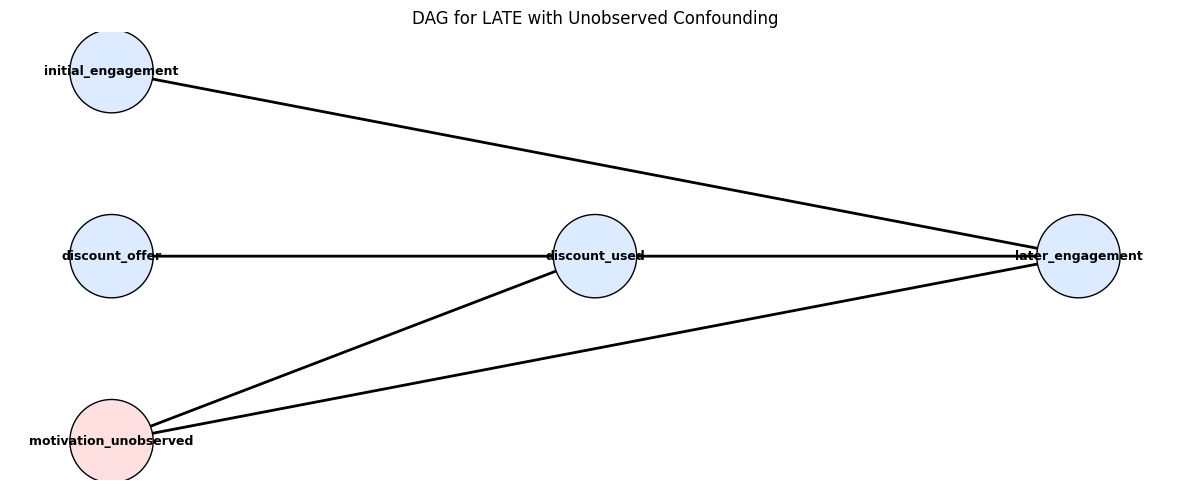


Puzzle answer
Use discount_offer groups, not discount_used groups.

Puzzle data
   initial_engagement  motivation_unobserved  discount_offer  discount_used  \
0                 0.2                    1.2               1              1   
1                -0.4                   -0.7               1              1   
2                 0.7                    0.4               1              0   
3                 1.0                   -0.2               1              1   
4                -0.3                    1.0               0              1   
5                 0.5                   -1.1               0              0   
6                -0.8                    0.3               0              0   
7                 0.1                   -0.5               0              0   

   later_engagement  
0               5.0  
1               3.0  
2               2.0  
3               4.0  
4               4.0  
5               1.0  
6               2.0  
7               1.0  

Rows wit

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)

print("Puzzle")
print("Suppose the eight rows below were the only rows in a small study.")
print()
print("The goal is to compute the LATE:")
print()
print("LATE = ITT_Y / ITT_D")
print()
print("where:")
print()
print("ITT_Y = mean(later_engagement | discount_offer = 1)")
print("        - mean(later_engagement | discount_offer = 0)")
print()
print("ITT_D = mean(discount_used | discount_offer = 1)")
print("        - mean(discount_used | discount_offer = 0)")
print()
print("Interpretation:")
print("ITT_Y measures the effect of being offered the discount on later_engagement.")
print("ITT_D measures the effect of being offered the discount on actually using the discount.")
print("LATE rescales the offer effect by the change in discount usage.")
print()
print("Important:")
print("Do not compute the naive difference by discount_used.")
print("For this puzzle, group rows by discount_offer, not by discount_used.")
print()
print("Compute:")
print("1. mean later_engagement among rows with discount_offer = 1")
print("2. mean later_engagement among rows with discount_offer = 0")
print("3. ITT_Y")
print("4. mean discount_used among rows with discount_offer = 1")
print("5. mean discount_used among rows with discount_offer = 0")
print("6. ITT_D")
print("7. LATE = ITT_Y / ITT_D")
print()

puzzle_data = pd.DataFrame({
    "initial_engagement": [0.2, -0.4, 0.7, 1.0, -0.3, 0.5, -0.8, 0.1],
    "motivation_unobserved": [1.2, -0.7, 0.4, -0.2, 1.0, -1.1, 0.3, -0.5],
    "discount_offer": [1, 1, 1, 1, 0, 0, 0, 0],
    "discount_used": [1, 1, 0, 1, 1, 0, 0, 0],
    "later_engagement": [5.0, 3.0, 2.0, 4.0, 4.0, 1.0, 2.0, 1.0]
})

print("Puzzle data")
print(puzzle_data)
print()

n = 1000

initial_engagement = np.random.normal(loc=0, scale=1, size=n)

motivation_unobserved = np.random.normal(loc=0, scale=1, size=n)

discount_offer = np.random.binomial(n=1, p=0.5, size=n)

logit_discount_used = (
    -1.0
    + 2.0 * discount_offer
    + 1.5 * motivation_unobserved
)

prob_discount_used = 1 / (1 + np.exp(-logit_discount_used))

discount_used = np.random.binomial(
    n=1,
    p=prob_discount_used,
    size=n
)

noise = np.random.normal(loc=0, scale=0.5, size=n)

later_engagement = (
    initial_engagement
    + 2.0 * discount_used
    + 1.5 * motivation_unobserved
    + noise
)

data = pd.DataFrame({
    "initial_engagement": initial_engagement,
    "motivation_unobserved": motivation_unobserved,
    "discount_offer": discount_offer,
    "discount_used": discount_used,
    "later_engagement": later_engagement
})

print("Dataset")
print(data)

naive_difference = (
    data.loc[data["discount_used"] == 1, "later_engagement"].mean()
    - data.loc[data["discount_used"] == 0, "later_engagement"].mean()
)

itt_y = (
    data.loc[data["discount_offer"] == 1, "later_engagement"].mean()
    - data.loc[data["discount_offer"] == 0, "later_engagement"].mean()
)

itt_d = (
    data.loc[data["discount_offer"] == 1, "discount_used"].mean()
    - data.loc[data["discount_offer"] == 0, "discount_used"].mean()
)

late = itt_y / itt_d

print("\nNaive difference in later_engagement by discount_used")
print(naive_difference)

print("\nITT effect of discount_offer on later_engagement")
print(itt_y)

print("\nITT effect of discount_offer on discount_used")
print(itt_d)

print("\nEstimated LATE")
print(late)

G = nx.DiGraph()

G.add_nodes_from([
    "initial_engagement",
    "motivation_unobserved",
    "discount_offer",
    "discount_used",
    "later_engagement"
])

G.add_edges_from([
    ("discount_offer", "discount_used"),
    ("discount_used", "later_engagement"),
    ("initial_engagement", "later_engagement"),
    ("motivation_unobserved", "discount_used"),
    ("motivation_unobserved", "later_engagement")
])

pos = {
    "initial_engagement": (0, 2),
    "motivation_unobserved": (0, -1),
    "discount_offer": (0, 0.5),
    "discount_used": (2.5, 0.5),
    "later_engagement": (5, 0.5)
}

plt.figure(figsize=(12, 5))

node_colors = [
    "#DCEBFF" if node != "motivation_unobserved" else "#FFE0E0"
    for node in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3600,
    node_color=node_colors,
    edgecolors="black"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9,
    font_weight="bold"
)

plt.title("DAG for LATE with Unobserved Confounding")
plt.axis("off")
plt.tight_layout()
plt.show()

print()
print("Puzzle answer")
print("Use discount_offer groups, not discount_used groups.")
print()

print("Puzzle data")
print(puzzle_data)
print()

mean_y_offer_1 = (
    puzzle_data.loc[
        puzzle_data["discount_offer"] == 1,
        "later_engagement"
    ].mean()
)

mean_y_offer_0 = (
    puzzle_data.loc[
        puzzle_data["discount_offer"] == 0,
        "later_engagement"
    ].mean()
)

puzzle_itt_y = mean_y_offer_1 - mean_y_offer_0

mean_d_offer_1 = (
    puzzle_data.loc[
        puzzle_data["discount_offer"] == 1,
        "discount_used"
    ].mean()
)

mean_d_offer_0 = (
    puzzle_data.loc[
        puzzle_data["discount_offer"] == 0,
        "discount_used"
    ].mean()
)

puzzle_itt_d = mean_d_offer_1 - mean_d_offer_0

puzzle_late = puzzle_itt_y / puzzle_itt_d

print("Rows with discount_offer = 1")
print(puzzle_data.loc[puzzle_data["discount_offer"] == 1])
print()

print("Rows with discount_offer = 0")
print(puzzle_data.loc[puzzle_data["discount_offer"] == 0])
print()

print("mean(later_engagement | discount_offer = 1)")
print("= (5.0 + 3.0 + 2.0 + 4.0) / 4")
print("=", mean_y_offer_1)
print()

print("mean(later_engagement | discount_offer = 0)")
print("= (4.0 + 1.0 + 2.0 + 1.0) / 4")
print("=", mean_y_offer_0)
print()

print("ITT_Y = mean(later_engagement | discount_offer = 1)")
print("        - mean(later_engagement | discount_offer = 0)")
print("ITT_Y =", mean_y_offer_1, "-", mean_y_offer_0)
print("ITT_Y =", puzzle_itt_y)
print()

print("mean(discount_used | discount_offer = 1)")
print("= (1 + 1 + 0 + 1) / 4")
print("=", mean_d_offer_1)
print()

print("mean(discount_used | discount_offer = 0)")
print("= (1 + 0 + 0 + 0) / 4")
print("=", mean_d_offer_0)
print()

print("ITT_D = mean(discount_used | discount_offer = 1)")
print("        - mean(discount_used | discount_offer = 0)")
print("ITT_D =", mean_d_offer_1, "-", mean_d_offer_0)
print("ITT_D =", puzzle_itt_d)
print()

print("LATE = ITT_Y / ITT_D")
print("LATE =", puzzle_itt_y, "/", puzzle_itt_d)
print("LATE =", puzzle_late)

# ITT = Intent To Treat
# Y = outcome
# D = Decision or Dose